# The Presentation Notebook


### 1 Basic imports and data, model directory 

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)       

# --------------------------------------------------
# Project paths
# --------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)

Project root: /Users/akashray/Lithology_Predictor
Data directory: /Users/akashray/Lithology_Predictor/data
Model directory: /Users/akashray/Lithology_Predictor/models


 # 2 Split and Frozen Model Configuration

This section loads the official FORCE 2020 well split and the feature metadata
associated with the three frozen production-candidate models.

No training or feature engineering is performed in this notebook.

In [2]:
# --------------------------------------------------
# Official split
# --------------------------------------------------

SPLIT_PATH = DATA_DIR / "splits" / "force2020_split.csv"

split_df = pd.read_csv(SPLIT_PATH)

# Expected official split structure
assert "WELL" in split_df.columns, "WELL column missing from split manifest."
assert "SPLIT" in split_df.columns, "SPLIT column missing from split manifest."

EXPECTED_SPLITS = {"TRAIN", "PUBLIC", "BLIND_TEST"}
assert set(split_df["SPLIT"].dropna().unique()) == EXPECTED_SPLITS, (
    f"Unexpected split labels: {split_df['SPLIT'].dropna().unique().tolist()}"
)

# Official blind wells
blind_wells = sorted(
    split_df.loc[split_df["SPLIT"] == "BLIND_TEST", "WELL"]
    .dropna()
    .unique()
)

assert len(blind_wells) == 10, (
    f"Expected 10 official blind wells, found {len(blind_wells)}."
)

# --------------------------------------------------
# Frozen model metadata
# --------------------------------------------------

W5_METADATA_PATH = MODEL_DIR / "w5_feature_metadata.json"
XGB_METADATA_PATH = MODEL_DIR / "xgboost_feature_metadata.json"
LGB_METADATA_PATH = MODEL_DIR / "lightgbm_feature_metadata.json"

with open(W5_METADATA_PATH, "r") as f:
    w5_metadata = json.load(f)

with open(XGB_METADATA_PATH, "r") as f:
    xgb_metadata = json.load(f)

with open(LGB_METADATA_PATH, "r") as f:
    lgb_metadata = json.load(f)

# --------------------------------------------------
# Verify identical feature representation
# --------------------------------------------------

w5_features = w5_metadata["features"]
xgb_features = xgb_metadata["features"]
lgb_features = lgb_metadata["features"]

assert len(w5_features) == 41
assert len(xgb_features) == 41
assert len(lgb_features) == 41

assert w5_features == xgb_features == lgb_features, (
    "The three frozen models do not use the same feature order."
)

FEATURES = w5_features

print("Official split loaded successfully.")
print("Split counts:")
print(split_df["SPLIT"].value_counts().to_string())

print("\nOfficial BLIND_TEST wells:")
for well in blind_wells:
    print(f"  {well}")

print("\nFrozen feature configuration:")
print(f"Number of ML features: {len(FEATURES)}")
print("Feature order verified: identical across W5, XGBoost and LightGBM.")

Official split loaded successfully.
Split counts:
SPLIT
TRAIN         98
PUBLIC        10
BLIND_TEST    10

Official BLIND_TEST wells:
  15_9-23
  16_2-7
  16_7-6
  17_4-1
  25_10-9
  31_2-10
  31_2-21 S
  34_3-2 S
  35_11-5
  35_9-7

Frozen feature configuration:
Number of ML features: 41
Feature order verified: identical across W5, XGBoost and LightGBM.


## 3. Load Frozen Dataset and Models

The engineered feature dataset and three previously trained models are loaded
without modification.

The models are evaluated exactly as saved; no retraining, tuning, imputation,
or feature engineering is performed in this notebook.

In [6]:
# --------------------------------------------------
# Frozen dataset and models
# --------------------------------------------------

TARGET_COL = "FORCE_2020_LITHOFACIES_LITHOLOGY"

assert TARGET_COL in engineered_df.columns, (
    f"Target column '{TARGET_COL}' not found."
)

# --------------------------------------------------
# Load frozen models
# --------------------------------------------------

W5_MODEL_PATH = MODEL_DIR / "lithology_w5_final.joblib"
XGB_MODEL_PATH = MODEL_DIR / "lithology_xgboost_final.joblib"
LGB_MODEL_PATH = MODEL_DIR / "lithology_lightgbm_final.joblib"

w5_model = joblib.load(W5_MODEL_PATH)
xgb_model = joblib.load(XGB_MODEL_PATH)
lgb_model = joblib.load(LGB_MODEL_PATH)

# --------------------------------------------------
# Verify model compatibility
# --------------------------------------------------

assert w5_model.n_features_in_ == len(FEATURES)
assert xgb_model.n_features_in_ == len(FEATURES)
assert lgb_model.n_features_in_ == len(FEATURES)

print("Frozen dataset and models loaded successfully.")

print("\nDataset:")
print(f"  Rows: {len(engineered_df):,}")
print(f"  Columns: {engineered_df.shape[1]}")
print(f"  Target: {TARGET_COL}")

print("\nModels:")
print(f"  W5:       {type(w5_model).__name__}")
print(f"  XGBoost:  {type(xgb_model).__name__}")
print(f"  LightGBM: {type(lgb_model).__name__}")

print("\nModel input:")
print(f"  Features: {len(FEATURES)}")
print("  Feature order: verified")

Frozen dataset and models loaded successfully.

Dataset:
  Rows: 1,430,974
  Columns: 46
  Target: FORCE_2020_LITHOFACIES_LITHOLOGY

Models:
  W5:       ExtraTreesClassifier
  XGBoost:  XGBClassifier
  LightGBM: LGBMClassifier

Model input:
  Features: 41
  Feature order: verified


## 4. Official BLIND_TEST Dataset

The evaluation dataset is constructed exclusively from the 10 wells designated
as `BLIND_TEST` in the official FORCE 2020 split manifest.

Only the frozen 41 model features and the official lithology target are used.

In [7]:
blind_mask = engineered_df["WELL"].isin(blind_wells)

blind_df = engineered_df.loc[
    blind_mask,
    ["WELL"] + FEATURES + [TARGET_COL]
].copy()


#validation

assert len(blind_df) == 122576, (
    f"Unexpected BLIND_TEST sample count: {len(blind_df):,}"
)

assert blind_df["WELL"].nunique() == 10, (
    f"Expected 10 blind wells, found {blind_df['WELL'].nunique()}"
)

assert set(blind_df["WELL"].unique()) == set(blind_wells), (
    "Extracted wells do not exactly match the official BLIND_TEST wells."
)

assert list(blind_df[FEATURES].columns) == FEATURES

assert blind_df[TARGET_COL].notna().all(), (
    "BLIND_TEST contains missing lithology labels."
)

print("Official BLIND_TEST dataset constructed successfully.")

print("\nShape:")
print(blind_df.shape)

print("\nSamples per blind well:")
print(
    blind_df["WELL"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nAll BLIND_TEST samples are labelled.")

Official BLIND_TEST dataset constructed successfully.

Shape:
(122576, 43)

Samples per blind well:
WELL
15_9-23      11063
16_2-7       11683
16_7-6       10222
17_4-1       17271
25_10-9      10788
31_2-10       9033
31_2-21 S     7840
34_3-2 S     12229
35_11-5      21770
35_9-7       10677

All BLIND_TEST samples are labelled.


## 5. Blind-Test Predictions

The three frozen models are applied directly to the official BLIND_TEST
feature matrix.

No retraining, tuning, resampling, or modification of the input features
is performed.

In [8]:
# --------------------------------------------------
# Prepare blind-test matrix
# --------------------------------------------------

X_blind = blind_df[FEATURES].copy()
y_blind = blind_df[TARGET_COL].to_numpy()

assert X_blind.shape == (122576, 41)
assert len(y_blind) == 122576
assert list(X_blind.columns) == FEATURES

# --------------------------------------------------
# Generate predictions
# --------------------------------------------------

w5_pred = w5_model.predict(X_blind)
xgb_pred = xgb_model.predict(X_blind)
lgb_pred = lgb_model.predict(X_blind)

# --------------------------------------------------
# Validate prediction outputs
# --------------------------------------------------

assert len(w5_pred) == len(y_blind)
assert len(xgb_pred) == len(y_blind)
assert len(lgb_pred) == len(y_blind)

assert not pd.isna(w5_pred).any()
assert not pd.isna(xgb_pred).any()
assert not pd.isna(lgb_pred).any()

print("Blind-test predictions generated successfully.")

print("\nPrediction shapes:")
print("W5:       ", w5_pred.shape)
print("XGBoost:  ", xgb_pred.shape)
print("LightGBM: ", lgb_pred.shape)

print("\nUnique predicted classes:")
print("W5:       ", np.sort(np.unique(w5_pred)))
print("XGBoost:  ", np.sort(np.unique(xgb_pred)))
print("LightGBM: ", np.sort(np.unique(lgb_pred)))

Blind-test predictions generated successfully.

Prediction shapes:
W5:        (122576,)
XGBoost:   (122576,)
LightGBM:  (122576,)

Unique predicted classes:
W5:        [30000. 65000. 65030. 70000. 70032. 74000. 80000. 86000. 88000. 90000.
 93000. 99000.]
XGBoost:   [ 0  1  2  3  4  5  6  7  8  9 11]
LightGBM:  [ 0  1  2  3  4  5  6  7  8  9 10 11]


## 6. Decode Model Predictions

XGBoost and LightGBM store lithology classes using internal integer indices.
The frozen label mapping created during model development is used to convert
these indices back to the original FORCE 2020 lithology codes.

In [9]:
# --------------------------------------------------
# Load frozen boosted-model label mapping
# --------------------------------------------------

MAPPING_PATH = MODEL_DIR / "boosted_label_mapping.json"

with open(MAPPING_PATH, "r") as f:
    label_mapping = json.load(f)

idx_to_code = {
    int(idx): int(code)
    for idx, code in label_mapping["idx_to_code"].items()
}

# Verify complete 12-class mapping
EXPECTED_INDICES = set(range(12))

assert set(idx_to_code.keys()) == EXPECTED_INDICES, (
    "Frozen label mapping does not contain all 12 model classes."
)

# --------------------------------------------------
# Decode XGBoost and LightGBM predictions
# --------------------------------------------------

xgb_pred_codes = np.array(
    [idx_to_code[int(x)] for x in xgb_pred],
    dtype=np.int64
)

lgb_pred_codes = np.array(
    [idx_to_code[int(x)] for x in lgb_pred],
    dtype=np.int64
)

w5_pred_codes = np.asarray(w5_pred, dtype=np.int64)
true_codes = np.asarray(y_blind, dtype=np.int64)

# --------------------------------------------------
# Validate decoded predictions
# --------------------------------------------------

valid_codes = set(idx_to_code.values())

assert set(np.unique(w5_pred_codes)).issubset(valid_codes)
assert set(np.unique(xgb_pred_codes)).issubset(valid_codes)
assert set(np.unique(lgb_pred_codes)).issubset(valid_codes)
assert set(np.unique(true_codes)).issubset(valid_codes)

print("Prediction decoding completed successfully.")

print("\nFrozen index → lithology code mapping:")
for idx in sorted(idx_to_code):
    print(f"  {idx:2d} → {idx_to_code[idx]}")

print("\nDecoded prediction classes:")
print("W5:       ", np.sort(np.unique(w5_pred_codes)))
print("XGBoost:  ", np.sort(np.unique(xgb_pred_codes)))
print("LightGBM: ", np.sort(np.unique(lgb_pred_codes)))

Prediction decoding completed successfully.

Frozen index → lithology code mapping:
   0 → 30000
   1 → 65000
   2 → 65030
   3 → 70000
   4 → 70032
   5 → 74000
   6 → 80000
   7 → 86000
   8 → 88000
   9 → 90000
  10 → 93000
  11 → 99000

Decoded prediction classes:
W5:        [30000 65000 65030 70000 70032 74000 80000 86000 88000 90000 93000 99000]
XGBoost:   [30000 65000 65030 70000 70032 74000 80000 86000 88000 90000 99000]
LightGBM:  [30000 65000 65030 70000 70032 74000 80000 86000 88000 90000 93000 99000]


## 7. Final Blind-Test Prediction Table

A single evaluation table is created containing the true lithology and the
predictions of all three frozen models for every sample in the official
10-well BLIND_TEST set.

In [10]:
# --------------------------------------------------
# Final blind-test prediction table
# --------------------------------------------------

blind_results = blind_df[["WELL", TARGET_COL]].copy()

blind_results = blind_results.rename(
    columns={TARGET_COL: "TRUE_LITHOLOGY"}
)

blind_results["W5_PREDICTION"] = w5_pred_codes
blind_results["XGBOOST_PREDICTION"] = xgb_pred_codes
blind_results["LIGHTGBM_PREDICTION"] = lgb_pred_codes

# --------------------------------------------------
# Validation
# --------------------------------------------------

EXPECTED_ROWS = 122576

assert blind_results.shape == (
    EXPECTED_ROWS,
    5
)

assert blind_results["WELL"].nunique() == 10

assert blind_results[
    ["TRUE_LITHOLOGY",
     "W5_PREDICTION",
     "XGBOOST_PREDICTION",
     "LIGHTGBM_PREDICTION"]
].notna().all().all()

assert len(blind_results) == len(blind_df)

print("Final blind-test prediction table created successfully.")

print("\nShape:", blind_results.shape)

print("\nColumns:")
for column in blind_results.columns:
    print(" ", column)

print("\nFirst 5 samples:")
print(blind_results.head().to_string())

Final blind-test prediction table created successfully.

Shape: (122576, 5)

Columns:
  WELL
  TRUE_LITHOLOGY
  W5_PREDICTION
  XGBOOST_PREDICTION
  LIGHTGBM_PREDICTION

First 5 samples:
          WELL  TRUE_LITHOLOGY  W5_PREDICTION  XGBOOST_PREDICTION  LIGHTGBM_PREDICTION
73674  15_9-23         65000.0          65000               65000                65000
73675  15_9-23         65000.0          65000               65000                65000
73676  15_9-23         65000.0          65000               65000                65000
73677  15_9-23         65000.0          65000               70000                65000
73678  15_9-23         65000.0          65000               65000                65000


In [11]:
blind_results


,WELL,TRUE_LITHOLOGY,W5_PREDICTION,XGBOOST_PREDICTION,LIGHTGBM_PREDICTION
73674,15_9-23,65000.0,65000,65000,65000
73675,15_9-23,65000.0,65000,65000,65000
73676,15_9-23,65000.0,65000,65000,65000
73677,15_9-23,65000.0,65000,70000,65000
73678,15_9-23,65000.0,65000,65000,65000
...,...,...,...,...,...
1404784,35_9-7,65000.0,65000,65030,65000
1404785,35_9-7,65000.0,65000,65000,65000
1404786,35_9-7,65000.0,65000,65000,65000
1404787,35_9-7,65000.0,65000,65000,65000


## 8. Overall Blind-Test Performance

Performance is evaluated across all 122,576 samples from the 10 official
BLIND_TEST wells using accuracy, balanced accuracy, macro F1, and weighted F1.

In [15]:
# --------------------------------------------------
# Overall blind-test metrics
# --------------------------------------------------

y_true = blind_results["TRUE_LITHOLOGY"].to_numpy()

# Only classes actually present in the official blind truth labels
evaluation_classes = np.sort(np.unique(y_true))

prediction_columns = {
    "W5 ExtraTrees": "W5_PREDICTION",
    "XGBoost": "XGBOOST_PREDICTION",
    "LightGBM": "LIGHTGBM_PREDICTION",
}

overall_metrics = []

for model_name, pred_column in prediction_columns.items():

    y_pred = blind_results[pred_column].to_numpy()

    overall_metrics.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            labels=evaluation_classes,
            average="macro",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_true,
            y_pred,
            labels=evaluation_classes,
            average="weighted",
            zero_division=0
        ),
    })

overall_metrics = pd.DataFrame(overall_metrics)

# --------------------------------------------------
# Validation
# --------------------------------------------------

assert overall_metrics.shape == (3, 5)

assert overall_metrics["Accuracy"].between(0, 1).all()
assert overall_metrics["Balanced Accuracy"].between(0, 1).all()
assert overall_metrics["Macro F1"].between(0, 1).all()
assert overall_metrics["Weighted F1"].between(0, 1).all()

print("Overall blind-test metrics calculated successfully.")
print(f"Evaluation classes: {len(evaluation_classes)}")
print()

print(
    overall_metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

Overall blind-test metrics calculated successfully.
Evaluation classes: 11

        Model  Accuracy  Balanced Accuracy  Macro F1  Weighted F1
W5 ExtraTrees  0.738676           0.463725  0.473372     0.713718
      XGBoost  0.676707           0.431236  0.391873     0.680074
     LightGBM  0.705252           0.482206  0.492300     0.703439


/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/akashray/Lithology_Predictor/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| W5 ExtraTrees | 0.738676 | 0.463725 | 0.433924 | 0.713718 |
| XGBoost | 0.676707 | 0.431236 | 0.391873 | 0.680074 |
| LightGBM | 0.705252 | 0.482206 | 0.451275 | 0.703439 |

## 9. FORCE 2020 Penalty Score

The official FORCE 2020 lithology penalty matrix is used to evaluate the
severity of classification errors.

A higher score is better. Because the penalty is represented as a negative
mean penalty, a value closer to zero indicates better performance.

In [16]:
# --------------------------------------------------
# FORCE 2020 penalty matrix
# --------------------------------------------------

force_classes = [
    30000, 65030, 65000, 80000, 74000, 70000,
    70032, 88000, 86000, 99000, 90000, 93000
]

penalty_matrix = np.array([
    [0,   2,   3,   3.5, 2.5, 3.5, 3,   3,   3,   3,   3,   3],
    [2,   0,   2,   3.5, 2.5, 3.5, 3,   3,   3,   3,   3,   3],
    [3,   2,   0,   3.5, 2.5, 3.5, 3,   3,   3,   3,   3,   3],
    [3.5, 3.5, 3.5, 0,   3,   2,   2.5, 3,   3,   3,   3,   3],
    [2.5, 2.5, 2.5, 3,   0,   3,   2.5, 3,   3,   3,   3,   3],
    [3.5, 3.5, 3.5, 2,   3,   0,   2,   3,   3,   3,   3,   3],
    [3,   3,   3,   2.5, 2.5, 2,   0,   3,   3,   3,   3,   3],
    [3,   3,   3,   3,   3,   3,   3,   0,   2,   3,   3,   3],
    [3,   3,   3,   3,   3,   3,   3,   3,   0,   3,   3,   3],
    [3,   3,   3,   3,   3,   3,   3,   3,   3,   0,   3,   3],
    [3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   0,   3],
    [3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   0]
], dtype=float)

assert penalty_matrix.shape == (12, 12)
assert np.all(np.diag(penalty_matrix) == 0)


def calculate_force_score(y_true, y_pred):
    """Calculate the negative mean FORCE 2020 penalty."""

    class_to_index = {
        code: index
        for index, code in enumerate(force_classes)
    }

    true_indices = np.array([
        class_to_index[int(value)]
        for value in y_true
    ])

    pred_indices = np.array([
        class_to_index[int(value)]
        for value in y_pred
    ])

    penalties = penalty_matrix[
        true_indices,
        pred_indices
    ]

    return -float(np.mean(penalties))


# --------------------------------------------------
# Calculate FORCE score for each model
# --------------------------------------------------

force_scores = {}

for model_name, pred_column in prediction_columns.items():

    force_scores[model_name] = calculate_force_score(
        y_true,
        blind_results[pred_column].to_numpy()
    )


# --------------------------------------------------
# Add FORCE score to the overall metrics table
# --------------------------------------------------

overall_metrics["FORCE Score"] = [
    force_scores["W5 ExtraTrees"],
    force_scores["XGBoost"],
    force_scores["LightGBM"],
]

print("FORCE 2020 scores calculated successfully.\n")

print(
    overall_metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

FORCE 2020 scores calculated successfully.

        Model  Accuracy  Balanced Accuracy  Macro F1  Weighted F1  FORCE Score
W5 ExtraTrees  0.738676           0.463725  0.473372     0.713718    -0.691942
      XGBoost  0.676707           0.431236  0.391873     0.680074    -0.840923
     LightGBM  0.705252           0.482206  0.492300     0.703439    -0.789278


| Model | Accuracy | Balanced Accuracy | **Macro F1** | Weighted F1 | FORCE |
|---|---:|---:|---:|---:|---:|
| **W5 ExtraTrees** | **73.87%** | 46.37% | **47.34%** | **71.37%** | **−0.691942** |
| XGBoost | 67.67% | 43.12% | 39.19% | 68.01% | −0.840923 |
| LightGBM | 70.53% | **48.22%** | **49.23%** | 70.34% | −0.789278 |

## 10. Per-Class Performance

Per-class precision, recall, and F1-score are calculated on the official
BLIND_TEST set to evaluate performance across both common and rare
lithologies.

In [17]:
# --------------------------------------------------
# Per-class performance
# --------------------------------------------------

per_class_results = []

for model_name, pred_column in prediction_columns.items():

    y_pred = blind_results[pred_column].to_numpy()

    report = classification_report(
        y_true,
        y_pred,
        labels=evaluation_classes,
        output_dict=True,
        zero_division=0
    )

    for code in evaluation_classes:
        code_str = str(code)

        per_class_results.append({
            "Model": model_name,
            "Lithology": int(code),
            "Precision": report[code_str]["precision"],
            "Recall": report[code_str]["recall"],
            "F1": report[code_str]["f1-score"],
            "Support": int(report[code_str]["support"]),
        })


per_class_results = pd.DataFrame(per_class_results)

# --------------------------------------------------
# Validation
# --------------------------------------------------

expected_rows = len(evaluation_classes) * len(prediction_columns)

assert per_class_results.shape[0] == expected_rows
assert set(per_class_results["Model"]) == set(prediction_columns.keys())
assert set(per_class_results["Lithology"]) == set(evaluation_classes)

assert per_class_results[
    ["Precision", "Recall", "F1"]
].apply(
    lambda column: column.between(0, 1).all()
).all()

print("Per-class performance calculated successfully.")
print(
    f"Classes evaluated: {len(evaluation_classes)}"
)
print(
    f"Models evaluated: {len(prediction_columns)}"
)
print(
    f"Total rows: {len(per_class_results)}"
)

Per-class performance calculated successfully.
Classes evaluated: 11
Models evaluated: 3
Total rows: 33


In [18]:
# --------------------------------------------------
# Per-class F1 comparison
# --------------------------------------------------

per_class_f1 = (
    per_class_results
    .pivot(
        index="Lithology",
        columns="Model",
        values="F1"
    )
    .reindex(evaluation_classes)
)

print("Per-class F1 score:")
print(
    per_class_f1.to_string(
        float_format=lambda x: f"{x:.3f}"
    )
)

Per-class F1 score:
Model      LightGBM  W5 ExtraTrees  XGBoost
Lithology                                  
30000.0       0.553          0.561    0.537
65000.0       0.849          0.883    0.867
65030.0       0.294          0.274    0.296
70000.0       0.568          0.532    0.556
70032.0       0.499          0.332    0.447
74000.0       0.006          0.103    0.000
80000.0       0.178          0.129    0.182
86000.0       0.701          0.735    0.159
88000.0       0.929          0.936    0.402
90000.0       0.669          0.684    0.674
99000.0       0.168          0.039    0.190


## 11. Confusion Matrices

Confusion matrices are used to examine lithology-specific classification
errors on the official BLIND_TEST set. Row-normalized matrices show the
distribution of predictions for each true lithology.

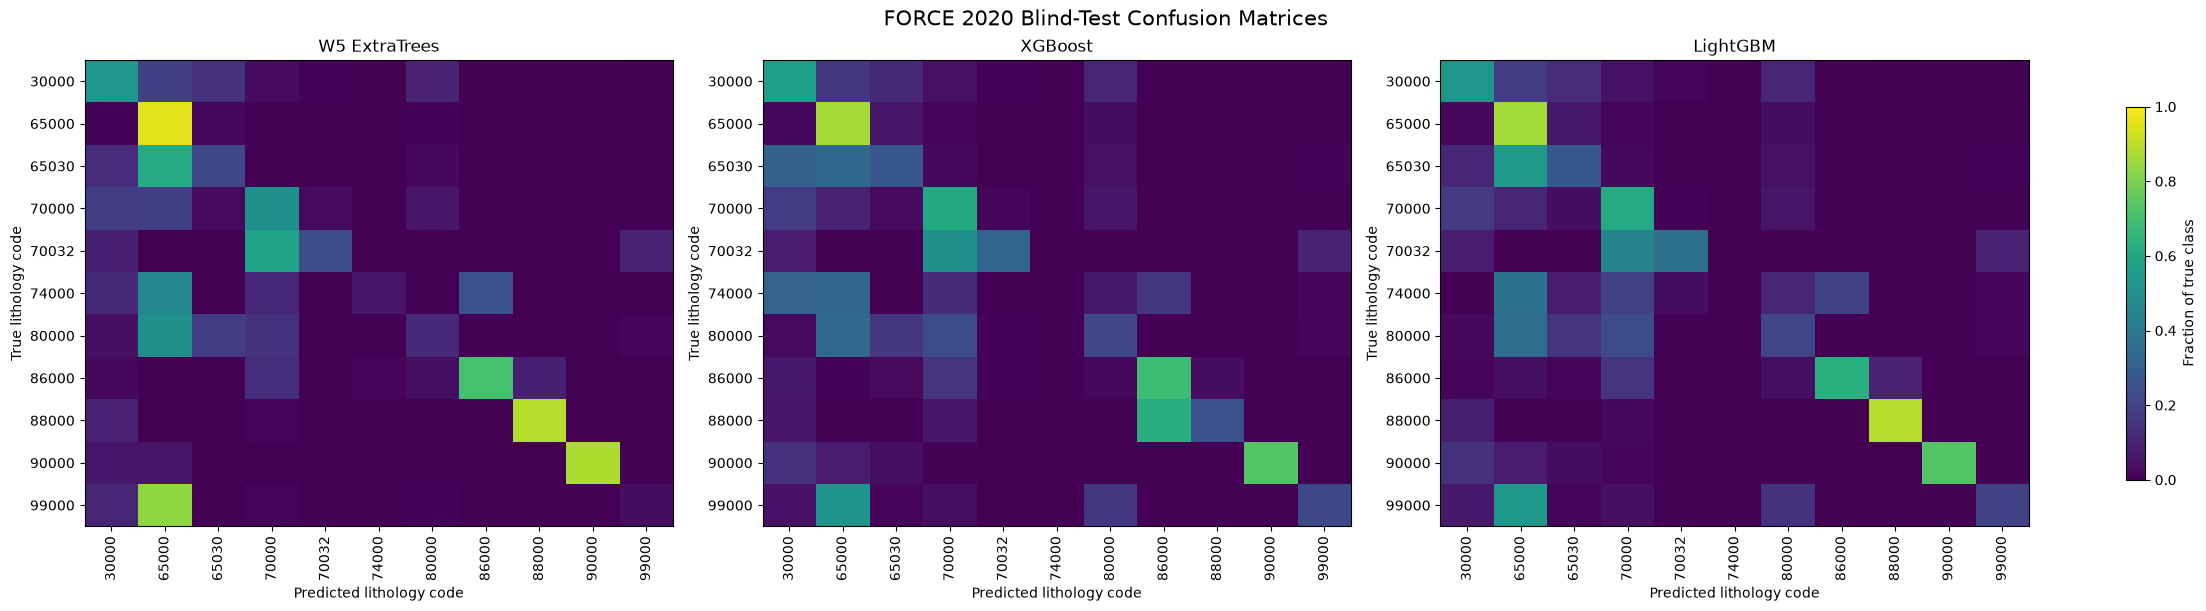

In [19]:
# --------------------------------------------------
# Row-normalized confusion matrices
# --------------------------------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_labels = evaluation_classes

fig, axes = plt.subplots(
    1, 3,
    figsize=(22, 6),
    constrained_layout=True
)

for ax, (model_name, pred_column) in zip(
    axes, prediction_columns.items()
):
    y_pred = blind_results[pred_column].to_numpy()

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_labels,
        normalize="true"
    )

    image = ax.imshow(
        cm,
        interpolation="nearest",
        aspect="auto",
        vmin=0,
        vmax=1
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted lithology code")
    ax.set_ylabel("True lithology code")

    ax.set_xticks(range(len(class_labels)))
    ax.set_yticks(range(len(class_labels)))

    ax.set_xticklabels(
        [str(int(c)) for c in class_labels],
        rotation=90
    )
    ax.set_yticklabels(
        [str(int(c)) for c in class_labels]
    )

fig.colorbar(
    image,
    ax=axes,
    label="Fraction of true class",
    shrink=0.8
)

fig.suptitle(
    "FORCE 2020 Blind-Test Confusion Matrices",
    fontsize=15
)

plt.show()

### Confusion Matrix Analysis

The row-normalized confusion matrices compare the true and predicted lithology classes for W5 ExtraTrees, XGBoost, and LightGBM on the official FORCE 2020 blind-test set. 

Strong diagonal values indicate correct classifications, while off-diagonal values reveal misclassification patterns. 

All three models perform well on 

Shale (`65000`), 

whereas Sandstone/Shale (`65030`), Dolomite (`74000`), Marl (`80000`), and Tuff (`99000`) 

show notable confusion with other lithologies.

W5 performs particularly well on Anhydrite (`86000`) and Halite (`88000`) compared with XGBoost. 

These patterns highlight class-specific differences that overall accuracy alone cannot capture.

# 12 Depth-Based Lithology Comparison

The true lithology and three model predictions are plotted against measured depth for an individual blind-test well. Depth is loaded separately from the visualization dataset and is not used as a model input.

In [22]:
# --------------------------------------------------
# Load depth and align it with blind-test predictions
# --------------------------------------------------

V2_PATH = DATA_DIR / "processed" / "engineered_features_v2.parquet"

depth_df = pd.read_parquet(V2_PATH, columns=["WELL", "DEPT"])

depth_df = depth_df.loc[
    depth_df["WELL"].isin(blind_wells),
    ["WELL", "DEPT"]
].copy()

# Preserve within-well sample order
depth_df["SAMPLE_NO"] = depth_df.groupby("WELL").cumcount()

blind_plot_df = blind_results.copy()
blind_plot_df["SAMPLE_NO"] = blind_plot_df.groupby("WELL").cumcount()

# Merge by well and within-well sample position
blind_plot_df = blind_plot_df.merge(
    depth_df,
    on=["WELL", "SAMPLE_NO"],
    how="left",
    validate="one_to_one"
)

# Validate alignment
assert len(blind_plot_df) == len(blind_results)
assert blind_plot_df["DEPT"].notna().all()
assert blind_plot_df["WELL"].nunique() == 10

print("Depth aligned successfully.")
print("Samples:", f"{len(blind_plot_df):,}")
print("Blind wells:", blind_plot_df["WELL"].nunique())

Depth aligned successfully.
Samples: 122,576
Blind wells: 10


In [63]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

lithology_info = {
    30000: ("Sandstone",       "#FFD700"),
    65030: ("Sandstone/Shale", "#7CFC00"),
    65000: ("Shale",           "#708090"),
    80000: ("Marl",            "#8A2BE2"),
    74000: ("Dolomite",        "#00CED1"),
    70000: ("Limestone",       "#00FFFF"),
    70032: ("Chalk",           "#F5F5DC"),
    88000: ("Halite",          "#FF1493"),
    86000: ("Anhydrite",       "#FF7F50"),
    99000: ("Tuff",            "#2F4F4F"),
    90000: ("Coal",            "#000000"),
    93000: ("Basement",        "#8B4513"),
}

codes_sorted = sorted(lithology_info)
code_to_idx = {c: i for i, c in enumerate(codes_sorted)}

lith_cmap = ListedColormap([lithology_info[c][1] for c in codes_sorted])
lith_norm = BoundaryNorm(np.arange(-0.5, len(codes_sorted) + 0.5, 1), lith_cmap.N)

In [64]:
def depth_edges(depth):
    mid = (depth[:-1] + depth[1:]) / 2
    return np.concatenate([[depth[0] - (mid[0] - depth[0])], mid,
                           [depth[-1] + (depth[-1] - mid[-1])]])


def plot_well_lithology(well, results=blind_plot_df, save_dir=None, figsize=(11, 18)):
    w = results[results["WELL"] == well].sort_values("DEPT")
    depth = w["DEPT"].to_numpy()
    edges = depth_edges(depth)

    tracks = [
        ("True",     "TRUE_LITHOLOGY"),
        ("W5",       "W5_PREDICTION"),
        ("XGBoost",  "XGBOOST_PREDICTION"),
        ("LightGBM", "LIGHTGBM_PREDICTION"),
    ]

    fig, axes = plt.subplots(1, len(tracks), figsize=figsize, sharey=True,
                             gridspec_kw={"wspace": 0.05})

    for ax, (title, col) in zip(axes, tracks):
        idx = w[col].astype(int).map(code_to_idx).to_numpy()
        ax.pcolormesh([0, 1], edges, idx[:, None], cmap=lith_cmap,
                      norm=lith_norm, shading="flat")
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xticks([])

    axes[0].set_ylim(depth.max(), depth.min())   # depth increases downward
    axes[0].set_ylabel("Depth (m)")

    present = set()
    for _, col in tracks:
        present |= set(w[col].astype(int).unique())
    handles = [Patch(facecolor=lithology_info[c][1], edgecolor="k",
                     label=lithology_info[c][0])
               for c in codes_sorted if c in present]
    fig.legend(handles=handles, title="Facies", loc="upper right",
               bbox_to_anchor=(1.0, 0.93), fontsize=9)

    fig.suptitle(f"Lithology: {well}", fontsize=14, fontweight="bold", y=0.93)

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"lithology_{well.replace(' ', '_')}.png",
                    dpi=200, bbox_inches="tight")
    return fig

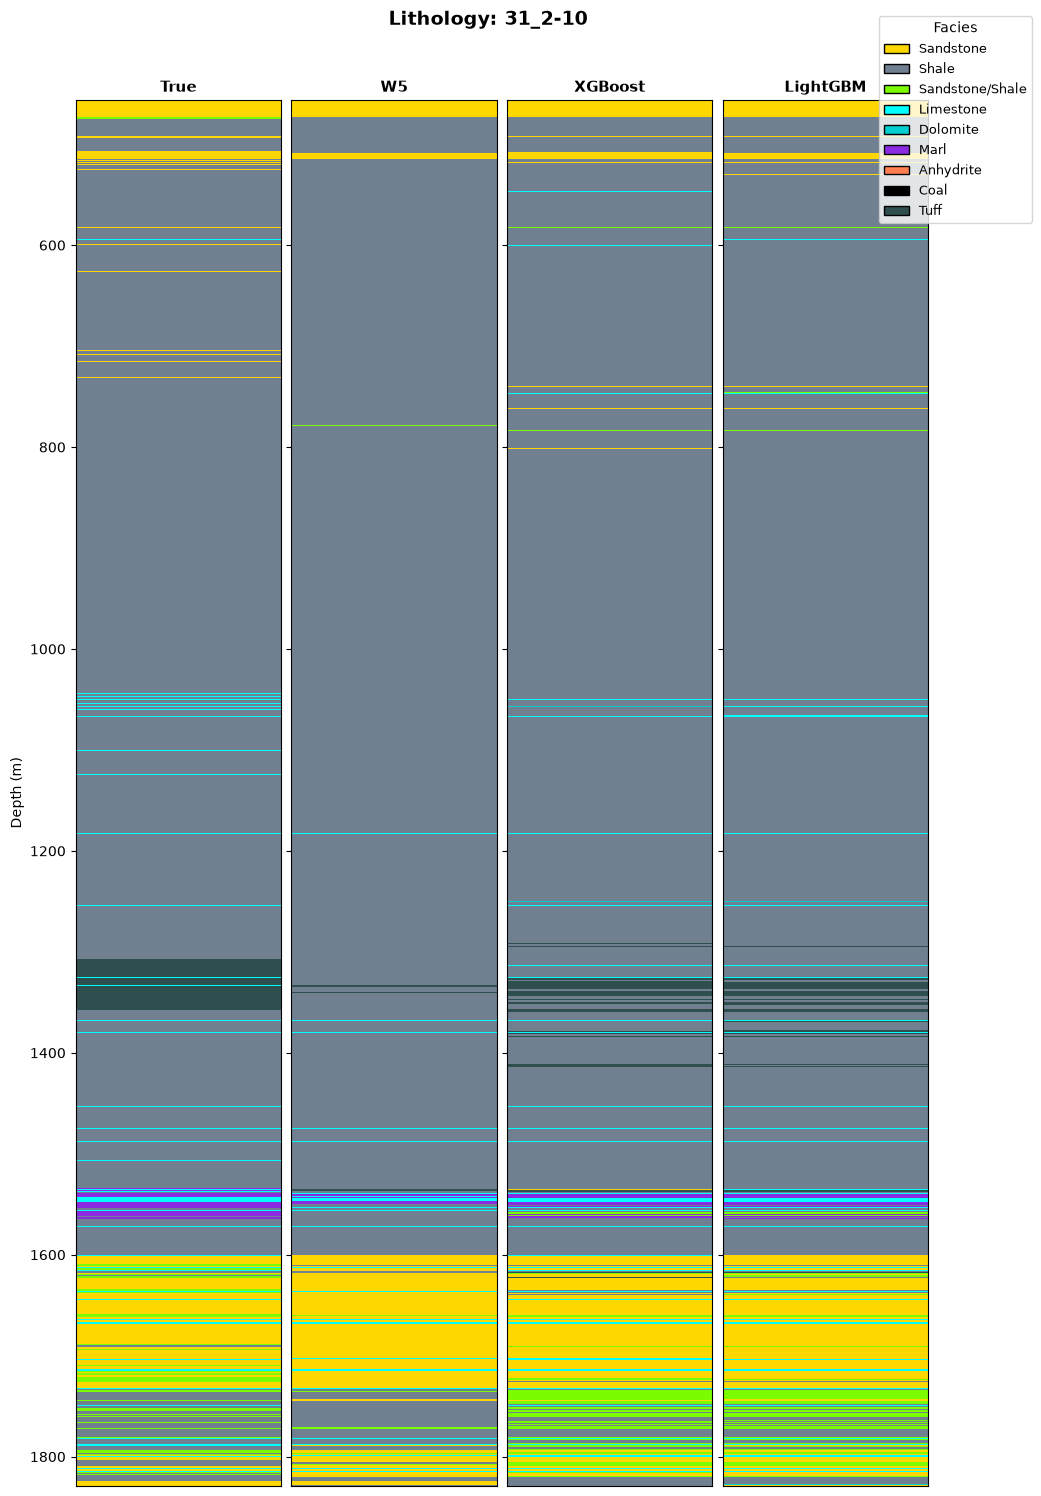

In [65]:
fig = plot_well_lithology("31_2-10")
plt.show()

In [66]:
# OUT_DIR = PROJECT_ROOT / "figures" / "blind_lithology"

# for well in blind_wells:
#     fig = plot_well_lithology(well, save_dir=OUT_DIR)
#     plt.show()
#     plt.close(fig)

# print("Saved to:", OUT_DIR)

# Official BLIND_TEST wells:
#   15_9-23
#   16_2-7
#   16_7-6
#   17_4-1
#   25_10-9
#   31_2-10
#   31_2-21 S
#   34_3-2 S
#   35_11-5
#   35_9-7

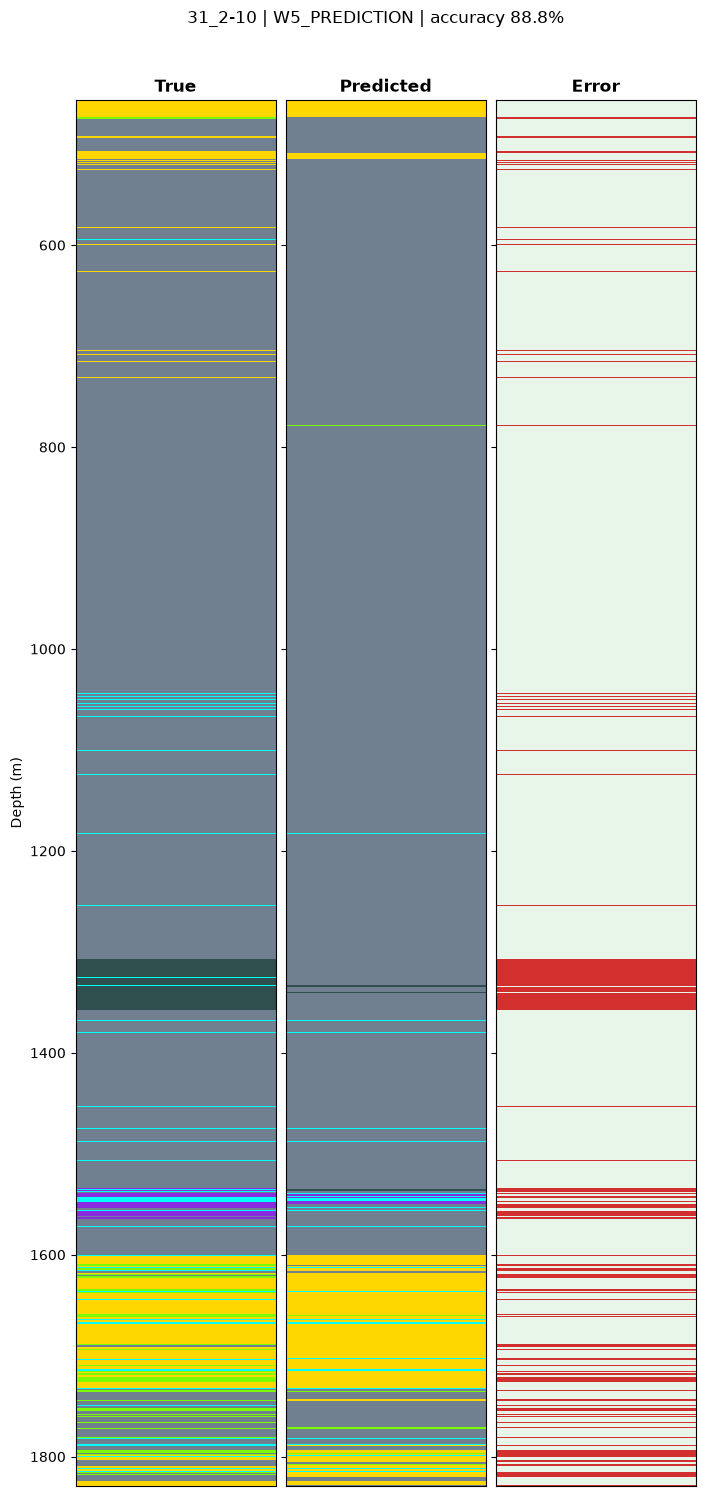

In [67]:
def plot_well_with_errors(well, pred_col="W5_PREDICTION", results=blind_plot_df):
    w = results[results["WELL"] == well].sort_values("DEPT")
    depth = w["DEPT"].to_numpy()
    edges = depth_edges(depth)

    fig, axes = plt.subplots(1, 3, figsize=(8, 18), sharey=True,
                             gridspec_kw={"wspace": 0.05})

    for ax, (title, col) in zip(axes[:2], [("True", "TRUE_LITHOLOGY"),
                                           ("Predicted", pred_col)]):
        idx = w[col].astype(int).map(code_to_idx).to_numpy()
        ax.pcolormesh([0, 1], edges, idx[:, None], cmap=lith_cmap, norm=lith_norm)
        ax.set_title(title, fontweight="bold")
        ax.set_xticks([])

    wrong = (w["TRUE_LITHOLOGY"].astype(int) != w[pred_col].astype(int)).astype(int).to_numpy()
    axes[2].pcolormesh([0, 1], edges, wrong[:, None],
                       cmap=ListedColormap(["#e8f5e9", "#d32f2f"]), vmin=0, vmax=1)
    axes[2].set_title("Error", fontweight="bold")
    axes[2].set_xticks([])

    axes[0].set_ylim(depth.max(), depth.min())
    axes[0].set_ylabel("Depth (m)")
    fig.suptitle(f"{well} | {pred_col} | accuracy {1 - wrong.mean():.1%}", y=0.93)
    return fig

plot_well_with_errors("31_2-10")
# plot_well_with_errors("34_3-2 S")

plt.show()

In [68]:
def plot_well_all_models_errors(well, results=blind_plot_df, save_dir=None,
                                figsize=(15, 40)):
    w = results[results["WELL"] == well].sort_values("DEPT")
    depth = w["DEPT"].to_numpy()
    edges = depth_edges(depth)

    models = [
        ("W5",       "W5_PREDICTION"),
        ("XGBoost",  "XGBOOST_PREDICTION"),
        ("LightGBM", "LIGHTGBM_PREDICTION"),
    ]

    n_tracks = 1 + 2 * len(models)          # True + (Pred + Error) x 3
    fig, axes = plt.subplots(
        1, n_tracks, figsize=figsize, sharey=True,
        gridspec_kw={"wspace": 0.05,
                     "width_ratios": [1] + [1, 0.45] * len(models)}
    )

    err_cmap = ListedColormap(["#e8f5e9", "#d32f2f"])
    true_int = w["TRUE_LITHOLOGY"].astype(int)

    # True track
    idx = true_int.map(code_to_idx).to_numpy()
    axes[0].pcolormesh([0, 1], edges, idx[:, None], cmap=lith_cmap, norm=lith_norm)
    axes[0].set_title("True", fontweight="bold")

    # Prediction + error tracks per model
    present = set(true_int.unique())
    for i, (name, col) in enumerate(models):
        ax_pred = axes[1 + 2 * i]
        ax_err = axes[2 + 2 * i]

        pred_int = w[col].astype(int)
        present |= set(pred_int.unique())

        ax_pred.pcolormesh([0, 1], edges,
                           pred_int.map(code_to_idx).to_numpy()[:, None],
                           cmap=lith_cmap, norm=lith_norm)

        wrong = (true_int != pred_int).astype(int).to_numpy()
        ax_err.pcolormesh([0, 1], edges, wrong[:, None],
                          cmap=err_cmap, vmin=0, vmax=1)

        acc = 1 - wrong.mean()
        ax_pred.set_title(f"{name}\n{acc:.1%}", fontweight="bold", fontsize=10)
        ax_err.set_title("Error", fontsize=9)

    for ax in axes:
        ax.set_xticks([])

    axes[0].set_ylim(depth.max(), depth.min())     # depth increases downward
    axes[0].set_ylabel("Depth (m)")

    # Legend (lithologies + error colours)
    handles = [Patch(facecolor=lithology_info[c][1], edgecolor="k",
                     label=lithology_info[c][0])
               for c in codes_sorted if c in present]
    handles += [Patch(facecolor="#e8f5e9", edgecolor="k", label="Correct"),
                Patch(facecolor="#d32f2f", edgecolor="k", label="Wrong")]
    fig.legend(handles=handles, title="Facies", loc="upper right",
               bbox_to_anchor=(1.0, 0.93), fontsize=9)

    fig.suptitle(f"Lithology: {well}", fontsize=14, fontweight="bold", y=0.94)

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"lithology_errors_{well.replace(' ', '_')}.png",
                    dpi=200, bbox_inches="tight")
    return fig

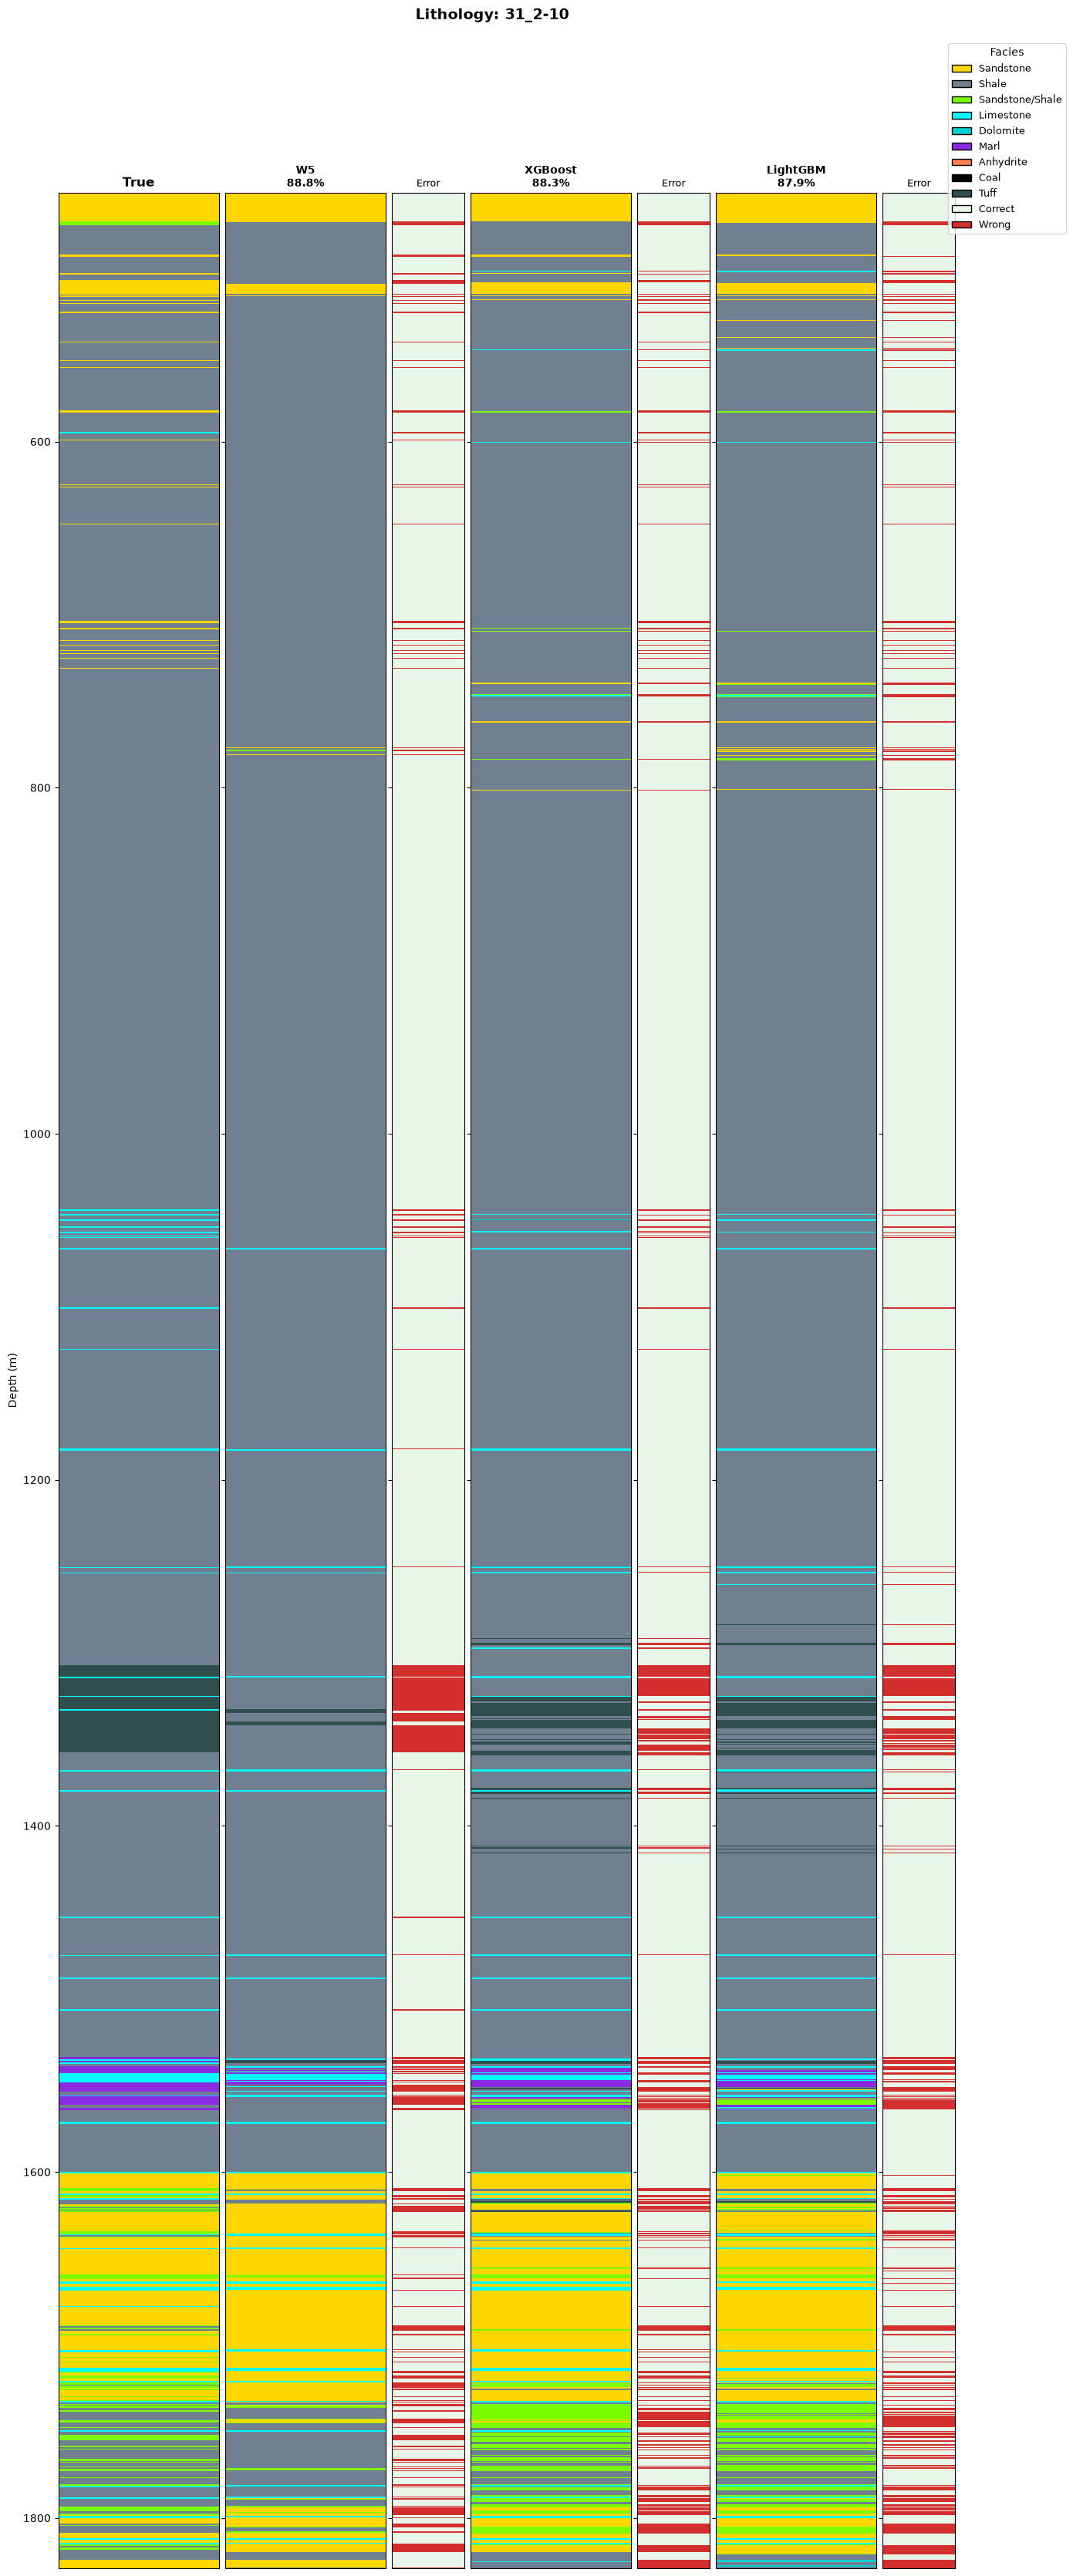

In [69]:
plot_well_all_models_errors("31_2-10")
plt.show()


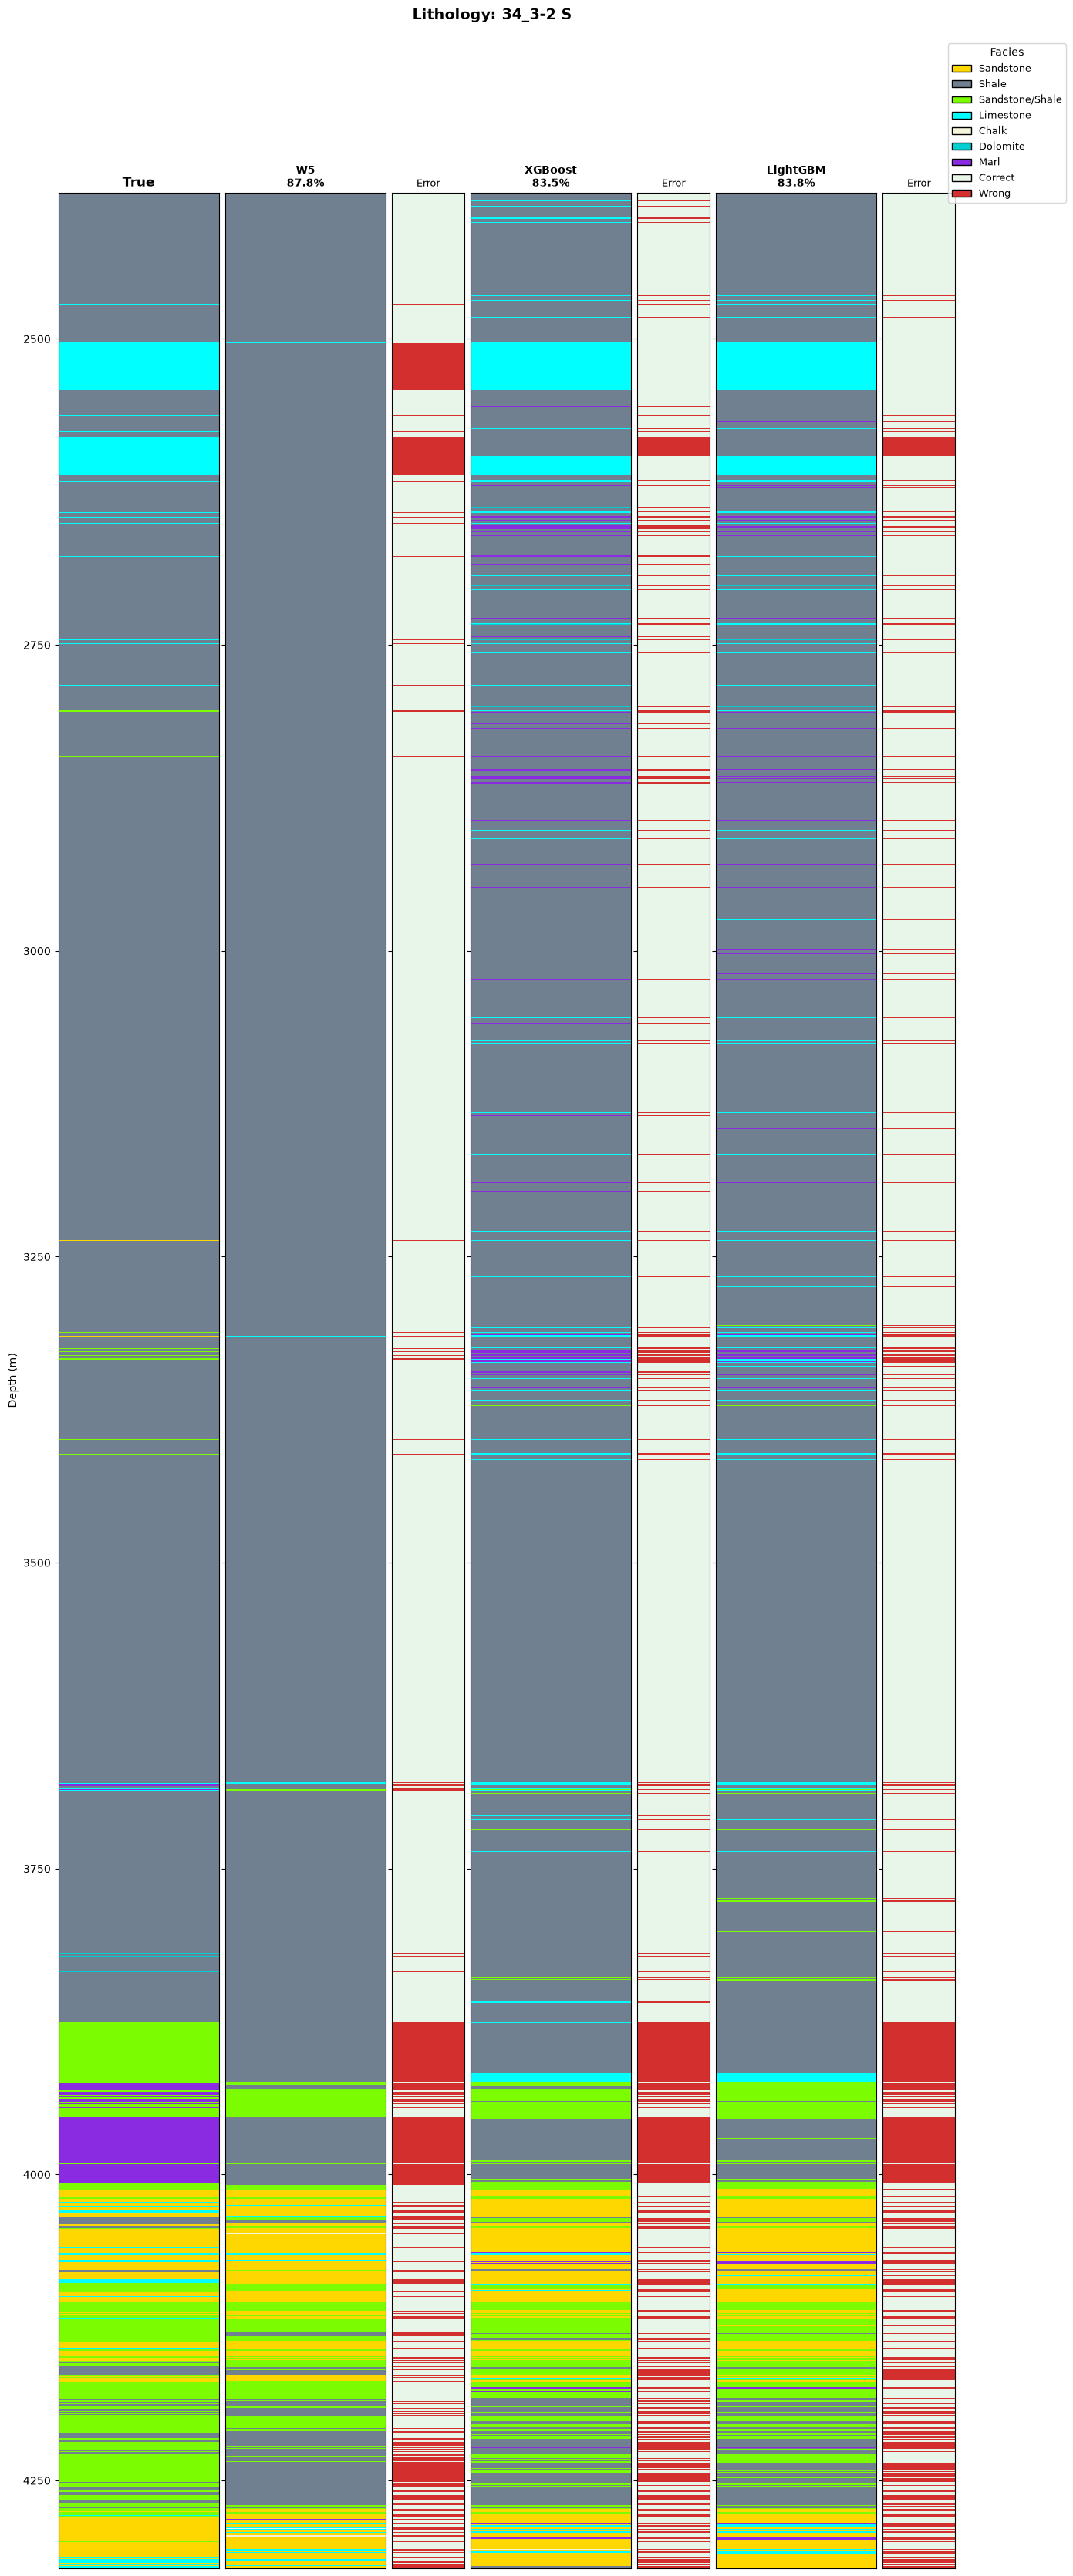

In [70]:
plot_well_all_models_errors("34_3-2 S")
plt.show()

## 13. Major Lithology Confusion Pairs

This section identifies the most frequent misclassification pairs for each model across the 122,576 samples in the official blind-test set. Counts and percentages are used to highlight which true lithologies are most often assigned to incorrect classes.

In [71]:
# --------------------------------------------------
# Top lithology confusion pairs for each model
# --------------------------------------------------

lithology_names = {
    30000: "Sandstone",
    65000: "Shale",
    65030: "Sandstone/Shale",
    70000: "Limestone",
    70032: "Chalk",
    74000: "Dolomite",
    80000: "Marl",
    86000: "Anhydrite",
    88000: "Halite",
    90000: "Coal",
    93000: "Basement",
    99000: "Tuff",
}

confusion_pair_tables = {}

for model_name, pred_column in prediction_columns.items():
    pairs = pd.DataFrame({
        "True": blind_results["TRUE_LITHOLOGY"].astype(int),
        "Predicted": blind_results[pred_column].astype(int),
    })

    # Keep incorrect predictions only
    pairs = pairs[pairs["True"] != pairs["Predicted"]]

    pair_counts = (
        pairs.groupby(["True", "Predicted"])
        .size()
        .reset_index(name="Count")
        .sort_values("Count", ascending=False)
        .head(10)
        .copy()
    )

    pair_counts["True Lithology"] = pair_counts["True"].map(lithology_names)
    pair_counts["Predicted Lithology"] = pair_counts["Predicted"].map(lithology_names)
    pair_counts["% of All Blind Samples"] = (
        100 * pair_counts["Count"] / len(blind_results)
    )

    confusion_pair_tables[model_name] = pair_counts[
        [
            "True",
            "Predicted",
            "True Lithology",
            "Predicted Lithology",
            "Count",
            "% of All Blind Samples",
        ]
    ]

    print(f"\n{model_name}: Top 10 confusion pairs")
    print(
        confusion_pair_tables[model_name].to_string(
            index=False,
            formatters={
                "% of All Blind Samples": "{:.2f}%".format
            }
        )
    )


W5 ExtraTrees: Top 10 confusion pairs
 True  Predicted  True Lithology Predicted Lithology  Count % of All Blind Samples
65030      65000 Sandstone/Shale               Shale   7579                  6.18%
30000      65000       Sandstone               Shale   2707                  2.21%
80000      65000            Marl               Shale   2190                  1.79%
30000      65030       Sandstone     Sandstone/Shale   2002                  1.63%
70032      70000           Chalk           Limestone   1689                  1.38%
65000      65030           Shale     Sandstone/Shale   1636                  1.33%
65030      30000 Sandstone/Shale           Sandstone   1560                  1.27%
70000      65000       Limestone               Shale   1558                  1.27%
70000      30000       Limestone           Sandstone   1525                  1.24%
30000      80000       Sandstone                Marl   1344                  1.10%

XGBoost: Top 10 confusion pairs
 True  Predicte

# 14 Major Misclassification Patterns

The top confusion pairs reveal that Shale (`65000`) and Sandstone/Shale (`65030`) are a major source of errors across all three models. W5 frequently assigns Sandstone, Marl, and Limestone samples to Shale, suggesting a tendency toward the dominant class. XGBoost shows a distinctive Halite-to-Anhydrite confusion, while LightGBM exhibits substantial confusion in both directions between Shale and Sandstone/Shale. These results indicate that overall accuracy alone does not fully capture the differences in model behavior across lithologies.

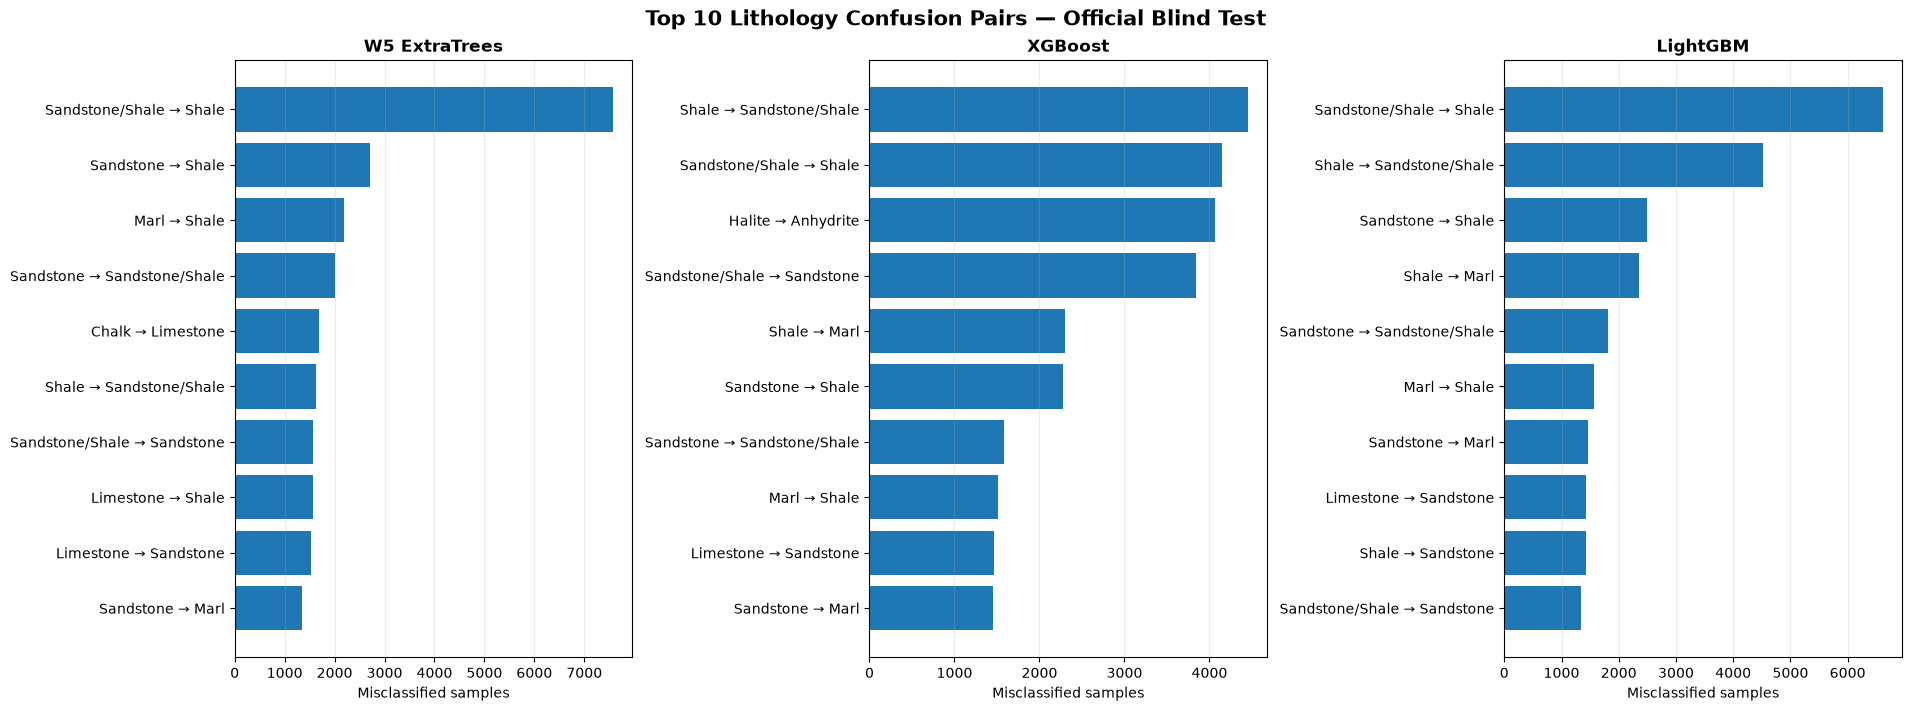

In [72]:
# --------------------------------------------------
# Plot top confusion pairs for each model
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 7),
    constrained_layout=True
)

for ax, (model_name, table) in zip(
    axes, confusion_pair_tables.items()
):
    plot_df = table.sort_values("Count", ascending=True)

    labels = [
        f"{true} → {pred}"
        for true, pred in zip(
            plot_df["True Lithology"],
            plot_df["Predicted Lithology"]
        )
    ]

    ax.barh(labels, plot_df["Count"])
    ax.set_title(model_name, fontweight="bold")
    ax.set_xlabel("Misclassified samples")
    ax.grid(axis="x", alpha=0.25)

fig.suptitle(
    "Top 10 Lithology Confusion Pairs — Official Blind Test",
    fontsize=15,
    fontweight="bold"
)

plt.show()

## 15. Final Results and Conclusions

### 15.1 Experimental Evaluation

Three frozen machine-learning models—W5 ExtraTrees, XGBoost, and LightGBM—were evaluated on the official FORCE 2020 blind-test set, comprising **122,576 labelled samples from 10 wells**. All models used the same 41 engineered input features.

### 15.2 Overall Model Performance

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | FORCE Score |
|---|---:|---:|---:|---:|---:|
| **W5 ExtraTrees** | **73.87%** | 46.37% | 47.34% | **71.37%** | **−0.691942** |
| XGBoost | 67.67% | 43.12% | 39.19% | 68.01% | −0.840923 |
| LightGBM | 70.53% | **48.22%** | **49.23%** | 70.34% | −0.789278 |

W5 ExtraTrees achieved the highest accuracy, weighted F1, and FORCE score. LightGBM achieved the highest balanced accuracy and macro F1, demonstrating comparatively stronger performance across the represented lithology classes when class-wise performance is considered.

### 15.3 Per-Class Performance and Error Analysis

The per-class evaluation revealed substantial variation in performance across lithologies.

- **Shale (`65000`)** was the strongest major class across all three models.
- **Sandstone (`30000`)** was classified moderately well, although confusion with Shale and Sandstone/Shale remained significant.
- **Sandstone/Shale (`65030`)** was difficult for all models, with frequent confusion with Shale and Sandstone.
- **Dolomite (`74000`)** and **Tuff (`99000`)** remained challenging classes.
- **Chalk (`70032`)** was frequently confused with Limestone (`70000`).
- XGBoost exhibited a prominent Halite (`88000`) to Anhydrite (`86000`) confusion.

The confusion matrices and depth-based visualizations further demonstrated that models can reproduce broad lithological intervals while disagreeing at individual samples and lithological boundaries.

### 15.4 Model Selection

The preferred model depends on the intended application:

- **W5 ExtraTrees:** preferred when overall accuracy, weighted F1, and the evaluated FORCE penalty score are the primary criteria.
- **LightGBM:** preferred when balanced accuracy and macro F1 are prioritized.
- **XGBoost:** provides a useful comparison baseline but achieved the lowest values among the three models for the reported overall metrics.

For the current project, **W5 ExtraTrees is the leading overall candidate**, while LightGBM remains an important alternative for further investigation of class-wise performance.

### 15.5 Limitations

The evaluation highlights several limitations:

1. The lithology distribution is highly imbalanced, which can favor common classes.
2. Some lithologies have limited representation, restricting the reliability of their class-wise evaluation.
3. Similar or mixed lithologies can have overlapping well-log responses.
4. Performance on the 10 official blind-test wells does not guarantee equivalent performance on wells from different geological settings.
5. Basement (`93000`) is absent from the true blind-test labels; therefore, its true-class performance cannot be evaluated on this set.

### 15.6 Final Conclusion

The experiments establish a reproducible comparison of three frozen lithology-classification models using the official FORCE 2020 blind-test wells. W5 ExtraTrees provides the strongest overall results under accuracy, weighted F1, and the calculated FORCE score, whereas LightGBM performs best under balanced accuracy and macro F1.

The remaining challenges are concentrated in minority lithologies and confusion between related or mixed facies. These findings provide a basis for future feature analysis, targeted model improvements, and integration into the Lithology Predictor web application.

The next development stage will focus on reliable LAS/CSV input validation, consistent feature preparation, model selection, depth-based lithology visualization, and downloadable prediction results.